<a href="https://colab.research.google.com/github/YTChiew/World-Internet-Usage-Data-Analyst/blob/main/World_Internet_02_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libraries & load dataset

import pandas as pd

df = pd.read_csv('internet_usage_cleaned.csv')
df.head()

,country,rate_wb,year_wb,rate_itu,year_itu,users_cia,year_cia,avg_internet_rate,latest_year
0,Afghanistan,18.4,2020,17.6,2019,7020000,2020.0,18.0,2020
1,Albania,83.1,2023,83.1,2023,2291000,2021.0,83.1,2023
2,Algeria,71.2,2022,71.2,2022,31240000,2021.0,71.2,2022
3,Andorra,94.5,2022,94.5,2022,74260,2021.0,94.5,2022
4,Angola,39.3,2022,39.3,2022,11550000,2021.0,39.3,2022


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            208 non-null    object 
 1   rate_wb            208 non-null    float64
 2   year_wb            208 non-null    int64  
 3   rate_itu           208 non-null    float64
 4   year_itu           208 non-null    int64  
 5   users_cia          208 non-null    int64  
 6   year_cia           207 non-null    float64
 7   avg_internet_rate  208 non-null    float64
 8   latest_year        208 non-null    int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 14.8+ KB


In [3]:
#Check overall distribution of average internet rate

df['avg_internet_rate'].describe()

,avg_internet_rate
count,208.000000
mean,70.521394
std,25.249434
min,9.050000
25%,54.350000
50%,78.950000
75%,89.900000
max,100.000000


Insights:
The average global internet rage stands at approximately 70.5%, indicating that a majority of the world's population has access to digital services. However, a significant digital divide persists, with some counties having penetration rates as low as 9%, while otheres have reached near-universal connectivity at 100%.

In [4]:
#Top10 vs Bottom10 countries

top10 = df.sort_values(by='avg_internet_rate', ascending=False).head(10)
top10[['country','avg_internet_rate']]

,country,avg_internet_rate
13,Bahrain,100.00
153,Qatar,100.00
196,United Arab Emirates,100.00
164,Saudi Arabia,100.00
85,Iceland,99.90
101,Kuwait,99.75
111,Luxembourg,99.35
27,Brunei,99.00
141,Norway,99.00
49,Denmark,98.85


In [5]:
bottom10 = df.sort_values(by='avg_internet_rate', ascending=True).head(10)
bottom10[['country','avg_internet_rate']]

,country,avg_internet_rate
36,Central African Republic,9.05
194,Uganda,10.00
30,Burundi,11.30
176,South Sudan,12.10
37,Chad,12.20
138,Niger,16.90
0,Afghanistan,18.00
61,Ethiopia,19.40
29,Burkina Faso,19.90
113,Madagascar,20.60


Insights: The top 10 countries exhibit internet penetration of approximately **98% and above**, indicating highly matured and saturated digital markets. In contrast the bottom 10 countries have penetrstion rates ranging from approximately **9% to 21%**, highlighting limited digital sccess and significant room for growth. This disparity suggests strong opportunities for expansion in digital services and supporting infrastructure within undeserved markets.

In [6]:
#Growth potential opportunity

df['growth_potential'] = 100 - df['avg_internet_rate']
df.head(10)

,country,rate_wb,year_wb,rate_itu,year_itu,users_cia,year_cia,avg_internet_rate,latest_year,growth_potential
0,Afghanistan,18.4,2020,17.6,2019,7020000,2020.0,18.00,2020,82.00
1,Albania,83.1,2023,83.1,2023,2291000,2021.0,83.10,2023,16.90
2,Algeria,71.2,2022,71.2,2022,31240000,2021.0,71.20,2022,28.80
3,Andorra,94.5,2022,94.5,2022,74260,2021.0,94.50,2022,5.50
4,Angola,39.3,2022,39.3,2022,11550000,2021.0,39.30,2022,60.70
5,Antigua and Barbuda,91.4,2022,91.4,2022,89280,2021.0,91.40,2022,8.60
6,Argentina,89.2,2023,89.2,2023,39150000,2021.0,89.20,2023,10.80
7,Armenia,78.6,2021,77.0,2022,2212000,2021.0,77.80,2022,22.20
8,Aruba,97.2,2017,97.2,2017,106800,2021.0,97.20,2017,2.80
9,Australia,95.0,2021,94.9,2022,24960000,2021.0,94.95,2022,5.05


In [7]:
#Top opportunities country

growth = df.sort_values(by='growth_potential', ascending=False).head(10)
growth[['country','growth_potential']]

,country,growth_potential
36,Central African Republic,90.95
194,Uganda,90.00
30,Burundi,88.70
176,South Sudan,87.90
37,Chad,87.80
138,Niger,83.10
0,Afghanistan,82.00
61,Ethiopia,80.60
29,Burkina Faso,80.10
113,Madagascar,79.40


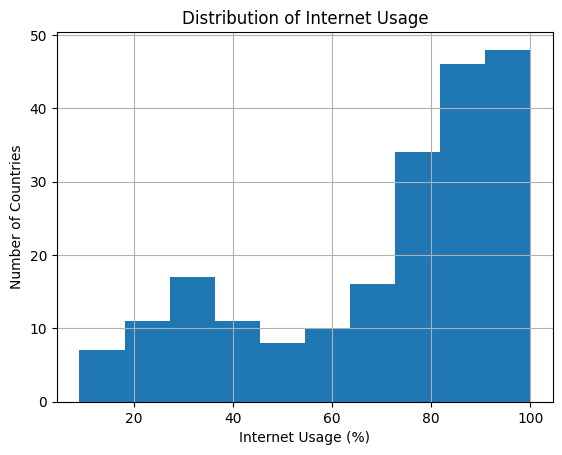

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
#Distribution of internet rate across countries

import matplotlib.pyplot as plt
import os
os.makedirs("images", exist_ok=True)

df['avg_internet_rate'].hist()
plt.title('Distribution of Internet Usage')
plt.xlabel('Internet Usage (%)')
plt.ylabel('Number of Countries')
plt.savefig("images/internet_across_countries_usage_distribution.png", bbox_inches="tight")
plt.show()

from google.colab import files
files.download("images/internet_across_countries_usage_distribution.png")


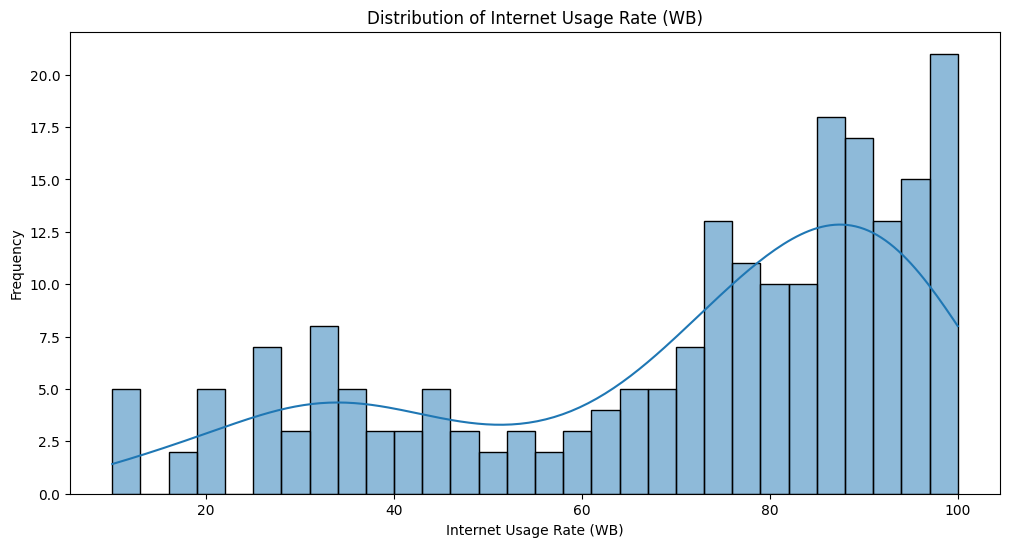

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
#Trend Analysis on Percentage of the population using the internet (World Bank data)

import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['rate_wb'], bins=30, kde=True)
plt.title('Distribution of Internet Usage Rate (WB)')
plt.xlabel('Internet Usage Rate (WB)')
plt.ylabel('Frequency')
plt.savefig("images/internet_penetration_rate_distribution.png", bbox_inches="tight")
plt.show()

from google.colab import files
files.download("images/internet_penetration_rate_distribution.png")